# Showcase — the 2023 Mediterranean marine heatwave (Copernicus Marine)

Through 2022–2023 the Mediterranean ran historically hot, with sea-surface temperatures far above the seasonal norm — a **marine heatwave (MHW)** that stressed marine ecosystems and fisheries. This notebook uses the earthlens **CMEMS** (Copernicus Marine) backend to pull a long daily SST record and applies the standard **Hobday et al. (2016)** MHW definition: days when SST exceeds the seasonally-varying **90th-percentile** climatology for at least five consecutive days.

> Uses the Copernicus Marine reprocessed SST product. Set `COPERNICUSMARINE_SERVICE_USERNAME` / `COPERNICUSMARINE_SERVICE_PASSWORD` (a free [Copernicus Marine](https://marine.copernicus.eu) account); the download cell skips gracefully without them.

## What this notebook does

1. **Download** ~13 years of daily reprocessed SST over a NW-Mediterranean box.
2. **Build the Hobday climatology** — a smoothed day-of-year mean and 90th percentile.
3. **Detect marine heatwaves** (SST > p90 for ≥5 days) and categorise their intensity (moderate → extreme).
4. **Visualise** the SST time series with the threshold and the MHW events shaded.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger
from pyramids.netcdf import NetCDF

from earthlens import EarthLens
from earthlens.base import AuthenticationError

logger.disable("earthlens")
logger.disable("pyramids")
USER = os.environ.get("COPERNICUSMARINE_SERVICE_USERNAME", "")
PWD = os.environ.get("COPERNICUSMARINE_SERVICE_PASSWORD", "")

# Reprocessed (long-record) Mediterranean L4 SST, daily. A small NW-Med box
# (Ligurian Sea) keeps the multi-year download tiny.
START, END = "2011-01-01", "2023-12-31"
sst_ts = None
el = EarthLens(
    data_source="cmems",
    cadence="daily",
    dataset="cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021",
    variables=["analysed_sst"],
    start=START,
    end=END,
    aoi=[6.5, 42.0, 9.0, 43.5],
    path=tempfile.mkdtemp(),
    service_username=USER,
    service_password=PWD,
)
try:
    el.authenticate()
except AuthenticationError as exc:  # noqa: BLE001
    print("CMEMS download skipped (needs credentials):", exc)
else:
    paths = el.download()
    nc = NetCDF.read_file(str(paths[0]), read_only=True)
    arr = np.asarray(nc.read_array("analysed_sst"), dtype="float32")
    nc.close()
    # analysed_sst is stored as int16 (scale_factor 0.01, add_offset 273.15,
    # fill -32768); read_array returns it undecoded, so decode to degrees C here
    # (the 273.15 K offset cancels when converting K -> C, leaving raw * 0.01).
    arr[arr < -30000] = np.nan
    daily = np.nanmean(arr * 0.01, axis=(1, 2))  # regional-mean SST in degC
    dates = pd.date_range(START, END, freq="D")[: len(daily)]
    sst_ts = pd.Series(daily, index=dates).dropna()
    print(
        f"{len(sst_ts)} daily SST values, {sst_ts.index[0].date()} -> {sst_ts.index[-1].date()}"
    )

4748 daily SST values, 2011-01-01 -> 2023-12-31


## The Hobday climatology and 90th-percentile threshold

For each calendar day we pool all years' SST within an 11-day window and take the **mean** (the seasonal climatology) and the **90th percentile** (the MHW threshold). A day is in a marine heatwave when SST exceeds that day's threshold.

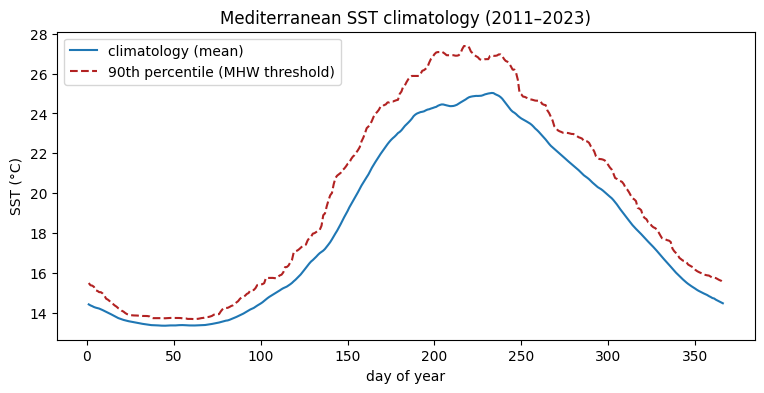

In [2]:
# Day-of-year climatology mean + 90th percentile over an 11-day window (Hobday).
if sst_ts is not None:
    doy = sst_ts.index.dayofyear.values
    vals = sst_ts.values
    clim = np.zeros(367)
    p90 = np.zeros(367)
    for d in range(1, 367):
        win = np.zeros_like(doy, dtype=bool)
        for off in range(-5, 6):
            win |= doy == ((d - 1 + off) % 366) + 1
        sample = vals[win]
        clim[d] = np.nanmean(sample)
        p90[d] = np.nanpercentile(sample, 90)
    clim_s = pd.Series(clim[doy], index=sst_ts.index)
    thr_s = pd.Series(p90[doy], index=sst_ts.index)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, 367), clim[1:], label="climatology (mean)")
    ax.plot(
        range(1, 367),
        p90[1:],
        "--",
        color="firebrick",
        label="90th percentile (MHW threshold)",
    )
    ax.set(
        xlabel="day of year",
        ylabel="SST (°C)",
        title="Mediterranean SST climatology (2011–2023)",
    )
    ax.legend()
    plt.show()

## Detect and categorise marine heatwaves

Following Hobday, an MHW is ≥5 consecutive days above the threshold. Intensity categories scale with how far SST sits above the climatology relative to the threshold gap: 1× = moderate, 2× = strong, 3× = severe, ≥4× = extreme.

In [3]:
# Runs of >=5 consecutive days above the p90 threshold = marine heatwaves.
if sst_ts is not None:
    above = (sst_ts > thr_s).values
    events = []
    i = 0
    n = len(above)
    while i < n:
        if above[i]:
            j = i
            while j < n and above[j]:
                j += 1
            if j - i >= 5:
                events.append((i, j))
            i = j
        else:
            i += 1
    gap = (thr_s - clim_s).clip(lower=0.1)
    cat_level = (sst_ts - clim_s) / gap
    total_days = sum(j - i for i, j in events)
    peak = (sst_ts - clim_s).idxmax()
    print(f"{len(events)} marine-heatwave events, {total_days} MHW days over 2011–2023")
    print(
        f"peak anomaly {float((sst_ts - clim_s).max()):+.1f} °C on {peak.date()} "
        f"(category {int(min(4, max(1, np.floor(cat_level.loc[peak]))))})"
    )

26 marine-heatwave events, 291 MHW days over 2011–2023
peak anomaly +4.3 °C on 2019-07-03 (category 2)


## SST time series with the marine heatwaves shaded

Zooming into 2021–2023 shows the prolonged, intense heatwaves of the 2022–2023 Mediterranean marine-heatwave period.

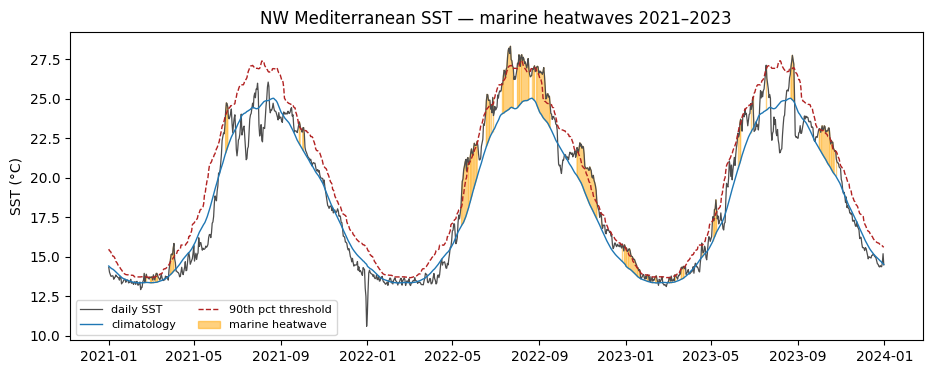

In [4]:
if sst_ts is not None:
    recent = sst_ts["2021":]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(recent.index, recent.values, color="0.3", lw=0.9, label="daily SST")
    ax.plot(
        recent.index,
        clim_s["2021":].values,
        color="tab:blue",
        lw=1,
        label="climatology",
    )
    ax.plot(
        recent.index,
        thr_s["2021":].values,
        "--",
        color="firebrick",
        lw=1,
        label="90th pct threshold",
    )
    mhw = recent > thr_s["2021":]
    ax.fill_between(
        recent.index,
        clim_s["2021":].values,
        recent.values,
        where=mhw.values,
        color="orange",
        alpha=0.5,
        label="marine heatwave",
    )
    ax.set(ylabel="SST (°C)", title="NW Mediterranean SST — marine heatwaves 2021–2023")
    ax.legend(ncol=2, fontsize=8)
    plt.show()

## Recap

The earthlens **CMEMS** backend delivers the long reprocessed SST record; applying the standard Hobday 90th-percentile definition turns it into marine-heatwave events with intensity categories — the workflow ocean scientists use to track MHWs.

## Try it yourself

- Move the box to the Aegean or the Balearic Sea, or extend the baseline to 1982.
- Add MHW duration/frequency trends, or compare basins.
- See the [CMEMS backend reference](../../reference/cmems/introduction.md).